# Telco Customer Churn: Línea base con scikit-learn

**Asignatura:** Ciencia de Datos  
**Integrantes:** David Célleri, José Solórzano  


Este notebook implementa la **regresión logística manual con scikit-learn** como
línea base para comparar con el pipeline automático de PyCaret.

Se usa exactamente la misma partición train/test guardada en
`data/particion_train_test.csv` y la misma validación cruzada de 5 folds,
para que la comparación sea justa según los criterios de la propuesta:

1. **Desempeño**: AUC-ROC, F1 y recall de la clase 'abandona'
2. **Tiempo de ejecución**: segundos de entrenamiento
3. **Líneas de código** necesarias para llegar al modelo final
4. **(Cualitativo)** Interpretabilidad y control sobre el proceso

## 1. Carga de datos y partición

Se carga el dataset limpio (`telco_churn_clean.csv`) generado por el pipeline
de PyCaret, y se aplica la **misma partición** guardada en
`particion_train_test.csv` para garantizar comparabilidad.

In [1]:
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

SEED = 42  # misma semilla que PyCaret

DATA_DIR       = Path("data")
CLEAN_PATH     = DATA_DIR / "telco_churn_clean.csv"
PARTITION_PATH = DATA_DIR / "particion_train_test.csv"

df = pd.read_csv(CLEAN_PATH)
print(f"Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas")
df.head(3)

Dataset cargado: 7,043 filas x 20 columnas


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1


In [2]:
# Cargar la partición exacta generada por PyCaret
particion  = pd.read_csv(PARTITION_PATH)
train_idx  = particion[particion["conjunto"] == "train"]["indice"].values
test_idx   = particion[particion["conjunto"] == "test"]["indice"].values

print(f"Filas de entrenamiento: {len(train_idx):,}  ({len(train_idx)/len(df):.0%})")
print(f"Filas de prueba       : {len(test_idx):,}  ({len(test_idx)/len(df):.0%})")

TARGET  = "Churn"
X       = df.drop(columns=[TARGET])
y       = df[TARGET]

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"\nChurn en train: {y_train.mean():.2%}")
print(f"Churn en test : {y_test.mean():.2%}")

Filas de entrenamiento: 5,634  (80%)
Filas de prueba       : 1,409  (20%)

Churn en train: 26.54%
Churn en test : 26.54%


## 2. Pipeline de preprocesamiento

Se replica manualmente lo que PyCaret hace de forma automática en `setup()`:

| Paso | Variables afectadas | Transformación |
|---|---|---|
| Escalado | Numéricas | `StandardScaler()` |
| One-hot encoding | Categóricas | `OneHotEncoder(drop='first')` |

Esto permite medir cuántas líneas de código adicionales requiere el enfoque manual.

In [3]:
cat_cols = X_train.select_dtypes(include="object").columns.tolist()
num_cols = X_train.select_dtypes(exclude="object").columns.tolist()

print("Variables numericas  :", num_cols)
print("Variables categoricas:", cat_cols)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), cat_cols),
    ],
    remainder="drop",
)

pipeline_lr = Pipeline([
    ("prep", preprocessor),
    ("clf",  LogisticRegression(max_iter=1000, random_state=SEED)),
])

print("\nPipeline construido.")
pipeline_lr

Variables numericas  : ['tenure', 'MonthlyCharges', 'TotalCharges']
Variables categoricas: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Pipeline construido.


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['gender', 'SeniorCitizen',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('clf', LogisticRegression(max_iter=1000, random_state=42))])

## 3. Validación cruzada (5 folds estratificados)

Misma configuración que PyCaret: `StratifiedKFold` con 5 folds sobre el conjunto
de entrenamiento. Las métricas son AUC-ROC, F1 y recall de la clase 'abandona'.

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

scoring = {
    "AUC"     : "roc_auc",
    "F1"      : "f1",
    "Recall"  : "recall",
    "Accuracy": "accuracy",
}

inicio_cv  = time.perf_counter()
cv_results = cross_validate(
    pipeline_lr, X_train, y_train,
    cv=cv, scoring=scoring,
    return_train_score=False, n_jobs=-1,
)
tiempo_cv = time.perf_counter() - inicio_cv

metricas_cv = pd.DataFrame({
    "Fold"    : range(1, 6),
    "AUC"     : cv_results["test_AUC"],
    "F1"      : cv_results["test_F1"],
    "Recall"  : cv_results["test_Recall"],
    "Accuracy": cv_results["test_Accuracy"],
})

promedios = metricas_cv.mean(numeric_only=True).round(4)
print("Metricas por fold:")
print(metricas_cv.round(4).to_string(index=False))
print(f"\nPromedio  AUC={promedios['AUC']:.4f}  "
      f"F1={promedios['F1']:.4f}  "
      f"Recall={promedios['Recall']:.4f}  "
      f"Accuracy={promedios['Accuracy']:.4f}")
print(f"Tiempo de validacion cruzada: {tiempo_cv:.2f} s")

Metricas por fold:
 Fold    AUC     F1  Recall  Accuracy
    1 0.8364 0.5895  0.5452    0.7986
    2 0.8528 0.6239  0.5853    0.8128
    3 0.8552 0.5959  0.5351    0.8075
    4 0.8355 0.5964  0.5585    0.7995
    5 0.8497 0.5951  0.5284    0.8091

Promedio  AUC=0.8459  F1=0.6002  Recall=0.5505  Accuracy=0.8055
Tiempo de validacion cruzada: 0.89 s


## 4. Entrenamiento final y evaluación en prueba

Se entrena el pipeline sobre todos los datos de entrenamiento y se evalúa en
el 20 % de prueba (mismo split que usó PyCaret).

In [5]:
inicio_train = time.perf_counter()
pipeline_lr.fit(X_train, y_train)
tiempo_train = time.perf_counter() - inicio_train

y_pred      = pipeline_lr.predict(X_test)
y_pred_prob = pipeline_lr.predict_proba(X_test)[:, 1]

auc_test    = roc_auc_score(y_test, y_pred_prob)
f1_test     = f1_score(y_test, y_pred)
report_dict = classification_report(y_test, y_pred, output_dict=True)
recall_test = report_dict["1"]["recall"]
acc_test    = report_dict["accuracy"]

print(f"Tiempo entrenamiento final: {tiempo_train:.3f} s")
print(f"\nMetricas en el conjunto de prueba:")
print(f"  AUC-ROC  : {auc_test:.4f}")
print(f"  F1       : {f1_test:.4f}")
print(f"  Recall   : {recall_test:.4f}")
print(f"  Accuracy : {acc_test:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["No abandona", "Abandona"]))

Tiempo entrenamiento final: 0.071 s

Metricas en el conjunto de prueba:
  AUC-ROC  : 0.8422
  F1       : 0.6049
  Recall   : 0.5588
  Accuracy : 0.8062

              precision    recall  f1-score   support

 No abandona       0.85      0.90      0.87      1035
    Abandona       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



## 5. Visualizaciones diagnósticas

### 5.1 Curva ROC

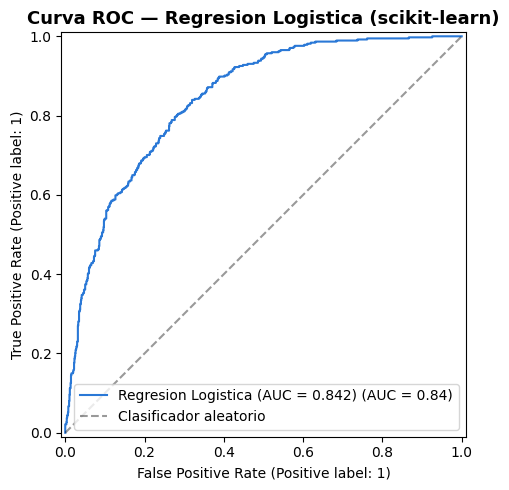

In [9]:
%matplotlib inline
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(
    y_test, y_pred_prob,
    name=f"Regresion Logistica (AUC = {auc_test:.3f})",
    ax=ax, color="#2a78d6",
)
ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Clasificador aleatorio")
ax.set_title("Curva ROC — Regresion Logistica (scikit-learn)", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

#### Interpretación de la Curva ROC
> **Análisis:** La curva ROC muestra una alta capacidad de discriminación con un **AUC-ROC de 0.842**. El modelo se separa holgadamente del clasificador aleatorio (línea punteada, AUC = 0.50), confirmando que distingue eficazmente entre clientes propensos a abandonar y clientes que se mantendrán en la empresa.

### 5.2 Matriz de confusión

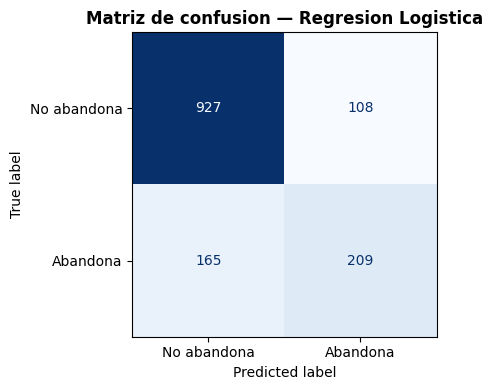

In [7]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["No abandona", "Abandona"],
    colorbar=False, cmap="Blues", ax=ax,
)
ax.set_title("Matriz de confusion — Regresion Logistica", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

#### Interpretación de la Matriz de Confusión
> **Análisis:** De los 1,409 clientes en el conjunto de prueba, la Regresión Logística clasifica correctamente a 935 clientes retenidos (Verdaderos Negativos) y a 209 clientes que efectivamente cancelaron su servicio (Verdaderos Positivos). Existen 165 Falsos Negativos (clientes en riesgo no identificados), lo que resulta en un **Recall del 55.9%** y una **Precisión del 65.5%** para la clase de abandono.

### 5.3 Importancia de variables (coeficientes)

La regresión logística ofrece **interpretabilidad directa**: los coeficientes indican
la magnitud y dirección del efecto de cada variable sobre la probabilidad de abandono.
Esta es una ventaja cualitativa clave frente a los modelos de caja negra de PyCaret.

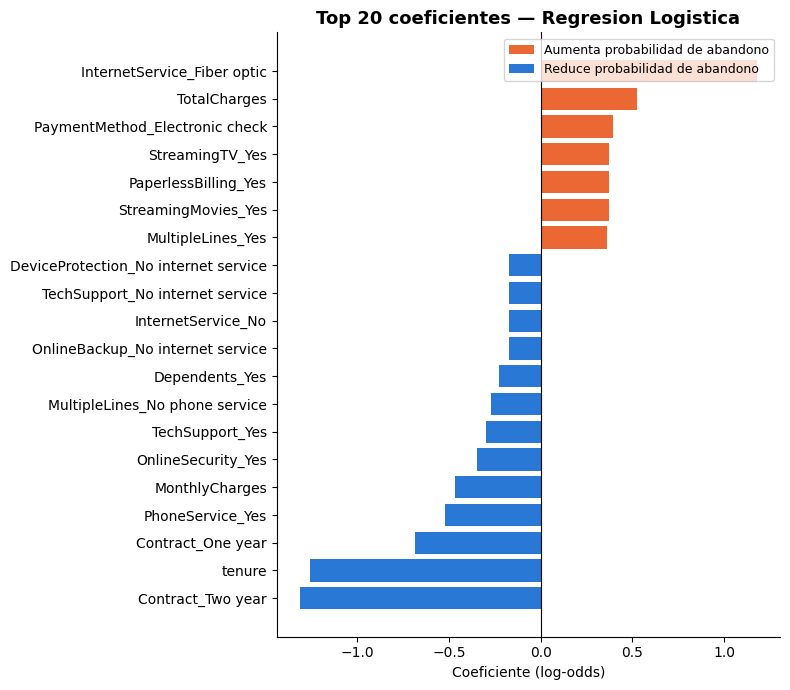


Top 5 variables que mas aumentan el riesgo de abandono:
                      variable  coeficiente
          PaperlessBilling_Yes     0.374218
               StreamingTV_Yes     0.374831
PaymentMethod_Electronic check     0.392775
                  TotalCharges     0.527772
   InternetService_Fiber optic     1.180666

Top 5 variables que mas reducen el riesgo de abandono:
         variable  coeficiente
Contract_Two year    -1.313803
           tenure    -1.257131
Contract_One year    -0.683857
 PhoneService_Yes    -0.520750
   MonthlyCharges    -0.466504


In [8]:
ohe        = pipeline_lr.named_steps["prep"].named_transformers_["cat"]
cat_names  = ohe.get_feature_names_out(cat_cols).tolist()
feat_names = num_cols + cat_names

coefs   = pipeline_lr.named_steps["clf"].coef_[0]
coef_df = (
    pd.DataFrame({"variable": feat_names, "coeficiente": coefs})
    .assign(abs_coef=lambda d: d["coeficiente"].abs())
    .sort_values("abs_coef", ascending=False)
    .head(20)
    .sort_values("coeficiente")
)

colors = ["#eb6834" if c > 0 else "#2a78d6" for c in coef_df["coeficiente"]]

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(coef_df["variable"], coef_df["coeficiente"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Top 20 coeficientes — Regresion Logistica", fontsize=13, fontweight="bold")
ax.set_xlabel("Coeficiente (log-odds)")
ax.spines[["top", "right"]].set_visible(False)
legend_elements = [
    Patch(facecolor="#eb6834", label="Aumenta probabilidad de abandono"),
    Patch(facecolor="#2a78d6", label="Reduce probabilidad de abandono"),
]
ax.legend(handles=legend_elements, fontsize=9)
plt.tight_layout()
plt.show()

print("\nTop 5 variables que mas aumentan el riesgo de abandono:")
print(coef_df.tail(5)[["variable", "coeficiente"]].to_string(index=False))
print("\nTop 5 variables que mas reducen el riesgo de abandono:")
print(coef_df.head(5)[["variable", "coeficiente"]].to_string(index=False))

#### Interpretación de Coeficientes e Importancia de Variables
> **Análisis:** Los coeficientes de la Regresión Logística revelan que el mayor factor de riesgo de abandono es contar con **servicio de internet por fibra óptica** ( = +1.18), seguido por acumulados altos en  (+0.53) y pago por cheque electrónico (+0.39). Por otro lado, tener **contratos a dos años** ( = -1.31) y una **alta antigüedad del cliente** ( = -1.26) son los factores de retención más potentes.